# 🚀 Predicting Fatalities in Terrorist Attacks
Enhanced ML Project with EDA, Visualization, and Advanced Models

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


In [ ]:
# Load Dataset
df = pd.read_csv("/content/Global Terrorism Data.csv", encoding='latin1')

/tmp/ipykernel_1763/3458277609.py:2: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Global Terrorism Data.csv", encoding='latin1')


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0.0,1.0,1.0,1.0,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN


In [ ]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0.0,1.0,1.0,1.0,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN


In [ ]:
# Basic Info
print(df.shape)
print(df.columns)

(160298, 135)
Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'addnotes', 'scite1', 'scite2', 'scite3', 'dbsource', 'INT_LOG',
       'INT_IDEO', 'INT_MISC', 'INT_ANY', 'related'],
      dtype='object', length=135)


In [ ]:
# Select Features
df = df[['nkill', 'weaptype1_txt', 'targtype1_txt', 'region_txt', 'iyear']]

In [ ]:
# Handle Missing Values
df['nkill'] = df['nkill'].fillna(0)
df.dropna(inplace=True)

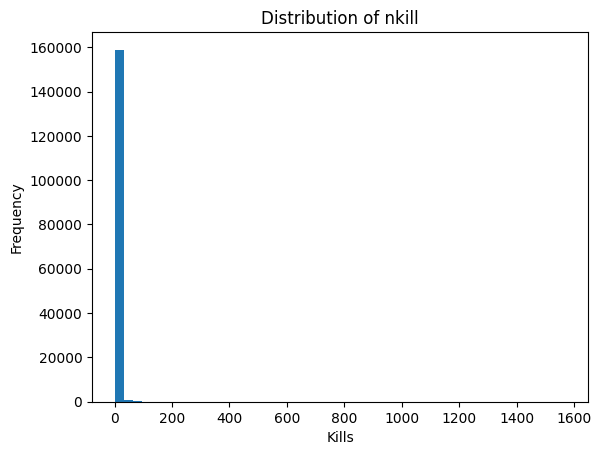

In [ ]:
# Distribution of Kills
plt.hist(df['nkill'], bins=50)
plt.title("Distribution of nkill")
plt.xlabel("Kills")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Remove Outliers
df = df[df['nkill'] < df['nkill'].quantile(0.99)]

In [ ]:
# Encoding
le = LabelEncoder()

df['weaptype1_txt'] = le.fit_transform(df['weaptype1_txt'])
df['targtype1_txt'] = le.fit_transform(df['targtype1_txt'])
df['region_txt'] = le.fit_transform(df['region_txt'])

In [ ]:
# Split Data
X = df.drop('nkill', axis=1)
y = df['nkill']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train Models

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost (if available)
#if xgb_available:
   # xgb = XGBRegressor()
  #  xgb.fit(X_train, y_train)
    #y_pred_xgb = xgb.predict(X_test)


In [ ]:
# Evaluation Function
def evaluate(name, y_test, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2:", r2_score(y_test, y_pred))

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)


Linear Regression
MAE: 1.9313726060856617
RMSE: 3.348080691329916
R2: 0.009364567478748365

Random Forest
MAE: 1.6711371589455883
RMSE: 3.175778324463073
R2: 0.10870312179354036


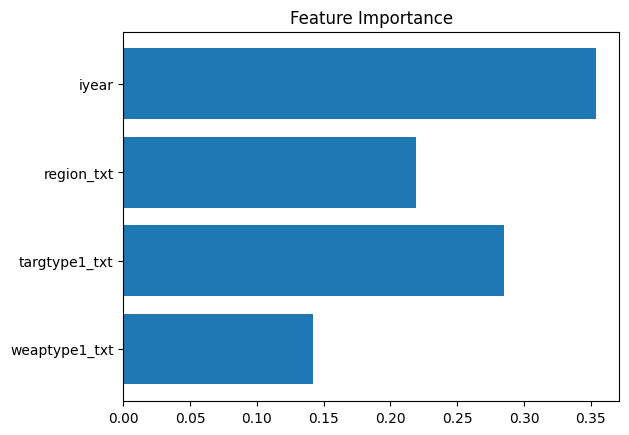

In [ ]:
# Feature Importance
importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [ ]:
# Sample Prediction
sample = [[2, 3, 1, 2015]]
print("Predicted kills:", rf.predict(sample)[0])

Predicted kills: 0.9868484848484848


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
